In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

df = pd.read_csv("incident records.csv")


Shape: (2997, 9)


In [22]:
df["date"] = pd.to_datetime(
    df["iyear"].astype(str) + "-" + df["imonth"].astype(str) + "-01"
)

monthly = df.groupby("date").size().reset_index(name="incidents")

prophet_df = monthly.rename(columns={"date": "ds", "incidents": "y"})

prophet_df = prophet_df.dropna(subset=["ds"])

In [24]:
model = Prophet()

In [25]:
model.fit(prophet_df)

15:24:32 - cmdstanpy - INFO - Chain [1] start processing


15:24:32 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=24, freq="MS")

forecast = model.predict(future)


,ds,yhat,yhat_lower,yhat_upper
226,2019-03-01,24.633754,13.212455,35.562418
227,2019-04-01,22.754223,11.782826,33.925437
228,2019-05-01,27.477916,16.124768,38.067634
229,2019-06-01,25.085666,13.753096,34.980296
230,2019-07-01,26.029090,15.118783,36.063362
231,2019-08-01,28.035296,16.511252,38.279856
232,2019-09-01,21.625895,10.376694,32.628951
233,2019-10-01,25.409960,14.499914,36.119881
234,2019-11-01,25.124649,14.023411,35.714413
235,2019-12-01,21.587620,10.552285,32.643403


Text(91.72222222222221, 0.5, 'Number of Incidents')

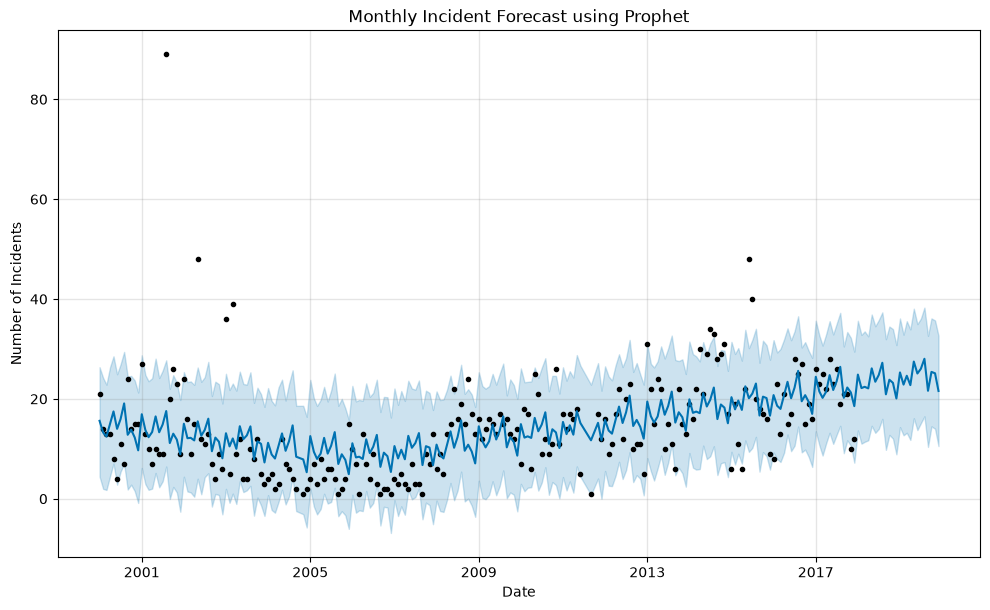

In [28]:
fig = model.plot(forecast)
plt.title("Monthly Incident Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Number of Incidents")

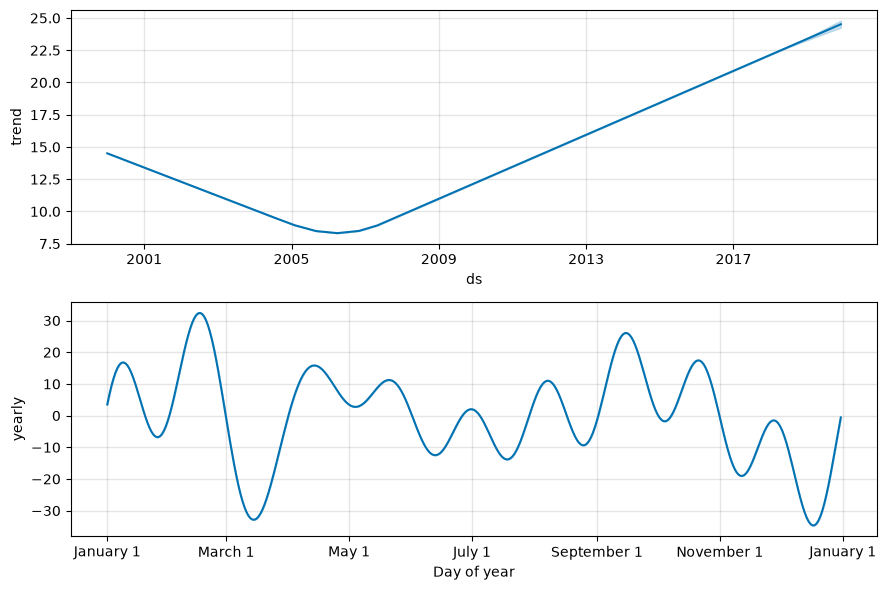

In [29]:
fig2 = model.plot_components(forecast)
plt.show()